In [74]:
import numpy as np
import sys
sys.path.insert(0, '/home/b085164/PDM_Romain_Defferrard/ESO-PDM/')

from lib.loaders import loadSBET
from scipy.spatial.transform import Rotation as R
from scipy.interpolate import interp1d
from scipy.signal import correlate, correlation_lags
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


In [75]:
PATH_AIRINS = '/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/base/reference.out'
PATH_APX    = '/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/traj_apx/sbet_ECCR_MLS_PUCK.out'

# mettre {'timeRef': 'UTC'} si le fichier est en UTC (ajoute 18s)
cfg_airins = {}
cfg_apx    = {}

t_air, lla_air, ecef_air, rpy_air = loadSBET(PATH_AIRINS, cfg_airins)
t_apx, lla_apx, ecef_apx, rpy_apx = loadSBET(PATH_APX,    cfg_apx)

print(f'\nAIRINS : {len(t_air):,} epochs')
print(f'  t_start = {t_air[0]:.6f} s  |  rpy_first = {np.degrees(rpy_air[0]).round(4)} deg')
print(f'  t_end   = {t_air[-1]:.6f} s  |  rpy_last  = {np.degrees(rpy_air[-1]).round(4)} deg')
print(f'\nAPX    : {len(t_apx):,} epochs')
print(f'  t_start = {t_apx[0]:.6f} s  |  rpy_first = {np.degrees(rpy_apx[0]).round(4)} deg')
print(f'  t_end   = {t_apx[-1]:.6f} s  |  rpy_last  = {np.degrees(rpy_apx[-1]).round(4)} deg')

t_start = max(t_air[0], t_apx[0])
t_end   = min(t_air[-1], t_apx[-1])
print(f'\nPlage commune : [{t_start:.3f}, {t_end:.3f}] s  ({(t_end-t_start)/60:.1f} min)')

Loading file /media/b085164/LaCie/2026spring_RD/ECCR/ODyN/base/reference.out
Loading file /media/b085164/LaCie/2026spring_RD/ECCR/ODyN/traj_apx/sbet_ECCR_MLS_PUCK.out

AIRINS : 1,278,857 epochs
  t_start = 313393.000000 s  |  rpy_first = [  -0.7867    1.3991 -158.9253] deg
  t_end   = 319483.800000 s  |  rpy_last  = [   0.6762    1.697  -165.871 ] deg

APX    : 1,150,527 epochs
  t_start = 313798.004291 s  |  rpy_first = [ -8.2952 -77.3438  28.2734] deg
  t_end   = 319551.004391 s  |  rpy_last  = [ -4.8997 -78.3519   9.6877] deg

Plage commune : [313798.004, 319483.800] s  (94.8 min)


In [76]:
def rpy_to_Rb2ned_seq(rpy):
    """
    RPY → R_body2NED = (R1@R2@R3).T pour chaque ligne.
    Convention SBET / rotations.py.
    Retourne ndarray (N, 3, 3).
    """
    r, p, y = rpy[:, 0], rpy[:, 1], rpy[:, 2]
    cr, sr = np.cos(r), np.sin(r)
    cp, sp = np.cos(p), np.sin(p)
    cy, sy = np.cos(y), np.sin(y)
    N = len(r)
    M = np.empty((N, 3, 3))
    M[:, 0, 0] = cp*cy;  M[:, 0, 1] = cy*sp*sr - cr*sy;  M[:, 0, 2] = cr*cy*sp + sr*sy
    M[:, 1, 0] = cp*sy;  M[:, 1, 1] = cr*cy + sp*sr*sy;  M[:, 1, 2] = -cy*sr + cr*sp*sy
    M[:, 2, 0] = -sp;    M[:, 2, 1] = cp*sr;              M[:, 2, 2] = cp*cr
    return M  # R_body2NED, shape (N, 3, 3)

In [77]:
# ── Grille commune = timestamps AIRINS dans la plage commune ──────────────────
mask_air  = (t_air >= t_start) & (t_air <= t_end)
t_grid    = t_air[mask_air]
rpy_air_g = rpy_air[mask_air]

# ── Interpolation RPY APX → grille AIRINS (interp1d) ─────────────────────────
# Les deux matrices R seront calculées aux MÊMES timestamps t_grid.
mask_apx  = (t_apx >= t_start - 1.0) & (t_apx <= t_end + 1.0)
t_apx_c   = t_apx[mask_apx]
rpy_apx_c = rpy_apx[mask_apx]

rpy_apx_g = np.zeros((len(t_grid), 3))
for i in range(3):
    f = interp1d(t_apx_c, rpy_apx_c[:, i], kind='linear',
                 bounds_error=False, fill_value=np.nan)
    rpy_apx_g[:, i] = f(t_grid)

# Retirer les NaN (bords)
valid     = np.all(~np.isnan(rpy_apx_g), axis=1)
t_grid    = t_grid[valid]
rpy_air_g = rpy_air_g[valid]
rpy_apx_g = rpy_apx_g[valid]

In [78]:
t_grid

array([313798.00841, 313798.01341, 313798.01842, ..., 319483.79173,
       319483.79673, 319483.8    ])

In [79]:


print(f'Points valides : {len(t_grid):,}  (NaN retirés : {(~valid).sum()})')
print(f'\nAIRINS @ grille — premier  t={t_grid[0]:.6f}  rpy={np.degrees(rpy_air_g[0]).round(4)} deg')
print(f'AIRINS @ grille — dernier  t={t_grid[-1]:.6f}  rpy={np.degrees(rpy_air_g[-1]).round(4)} deg')
print(f'\nAPX    @ grille — premier  t={t_grid[0]:.6f}  rpy={np.degrees(rpy_apx_g[0]).round(4)} deg')
print(f'APX    @ grille — dernier  t={t_grid[-1]:.6f}  rpy={np.degrees(rpy_apx_g[-1]).round(4)} deg')

# ── Conversion RPY → matrices R_body2NED aux mêmes timestamps ─────────────────
R_air_b2ned   = rpy_to_Rb2ned_seq(rpy_air_g)   # (N, 3, 3)  AIRINS
R_apx_b2ned_g = rpy_to_Rb2ned_seq(rpy_apx_g)   # (N, 3, 3)  APX (même grille)

print(f'\nR_air_b2ned   shape : {R_air_b2ned.shape}')
print(f'R_apx_b2ned_g shape : {R_apx_b2ned_g.shape}')
print(f'\nR_air_b2ned   [0]  :\n{np.round(R_air_b2ned[0], 6)}')
print(f'R_air_b2ned   [-1] :\n{np.round(R_air_b2ned[-1], 6)}')
print(f'\nR_apx_b2ned_g [0]  :\n{np.round(R_apx_b2ned_g[0], 6)}')
print(f'R_apx_b2ned_g [-1] :\n{np.round(R_apx_b2ned_g[-1], 6)}')

Points valides : 1,193,805  (NaN retirés : 0)

AIRINS @ grille — premier  t=313798.008410  rpy=[   1.4797    0.7705 -159.4449] deg
AIRINS @ grille — dernier  t=319483.800000  rpy=[   0.6762    1.697  -165.871 ] deg

APX    @ grille — premier  t=313798.008410  rpy=[ -8.2976 -77.3537  28.2736] deg
APX    @ grille — dernier  t=319483.800000  rpy=[ -4.9314 -78.3629  10.4476] deg

R_air_b2ned   shape : (1193805, 3, 3)
R_apx_b2ned_g shape : (1193805, 3, 3)

R_air_b2ned   [0]  :
[[-0.936251  0.350665 -0.021654]
 [-0.351075 -0.936145  0.019459]
 [-0.013448  0.025821  0.999576]]
R_air_b2ned   [-1] :
[[-0.969323  0.24375  -0.031598]
 [-0.243999 -0.969766  0.004216]
 [-0.029615  0.011797  0.999492]]

R_apx_b2ned_g [0]  :
[[ 0.192812 -0.344711 -0.918694]
 [ 0.103704  0.938177 -0.330256]
 [ 0.97574  -0.031595  0.21664 ]]
R_apx_b2ned_g [-1] :
[[ 0.198368 -0.097864 -0.97523 ]
 [ 0.036578  0.995049 -0.092413]
 [ 0.979445 -0.01734   0.200965]]


In [80]:

# ── TESTS ─────────────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('TESTS DE COHÉRENCE')
print('='*55)

# Test 1 : RPY interpolés dans la plage des bruts
print('\nTest 1 — plage RPY interpolés vs bruts :')
for i, name in enumerate(['roll', 'pitch', 'yaw']):
    mn_r, mx_r = rpy_apx_c[:, i].min(), rpy_apx_c[:, i].max()
    mn_i, mx_i = rpy_apx_g[:, i].min(), rpy_apx_g[:, i].max()
    ok = (mn_i >= mn_r - 1e-6) and (mx_i <= mx_r + 1e-6)
    print(f'  {name:5s} : [{np.degrees(mn_r):+.3f}°, {np.degrees(mx_r):+.3f}°]  '
          f'interp=[{np.degrees(mn_i):+.3f}°, {np.degrees(mx_i):+.3f}°]  '
          f'[{"OK" if ok else "WARN"}]')

# Test 2 : l'interpolé coïncide avec les bruts aux timestamps APX
print('\nTest 2 — cohérence aux timestamps APX bruts (5 points) :')
f_test = interp1d(t_apx_c, rpy_apx_c, axis=0, kind='linear')
idx_test = np.linspace(len(t_apx_c)//4, 3*len(t_apx_c)//4, 5, dtype=int)
max_err = 0.0
for idx in idx_test:
    err = np.max(np.abs(np.degrees(rpy_apx_c[idx] - f_test(t_apx_c[idx]))))
    max_err = max(max_err, err)
print(f'  Erreur max : {max_err:.2e} deg  [{"OK" if max_err < 1e-6 else "FAIL"}]')

# Test 3 : orthogonalité des deux séquences de matrices
for label, M in [('R_air_b2ned', R_air_b2ned), ('R_apx_b2ned_g', R_apx_b2ned_g)]:
    err = np.max(np.abs(np.einsum('nij,nkj->nik', M, M) - np.eye(3)))
    print(f'\nTest 3 — orthogonalité {label} : max err = {err:.2e}  '
          f'[{"OK" if err < 1e-10 else "WARN"}]')

# Test 4 : synchronisation temporelle via cross-corrélation sur le pitch
print('\nTest 4 — synchronisation (cross-corr pitch) :')
dt = float(np.median(np.diff(t_grid)))
a  = rpy_air_g[:, 1] - rpy_air_g[:, 1].mean()
b  = rpy_apx_g[:, 1] - rpy_apx_g[:, 1].mean()
a /= (np.std(a) + 1e-12); b /= (np.std(b) + 1e-12)
cc   = correlate(a, b, mode='full')
lags = correlation_lags(len(a), len(b), mode='full') * dt * 1000
lag_ms = lags[np.argmax(np.abs(cc))]
print(f'  Lag optimal = {lag_ms:+.1f} ms  '
      f'[{"OK — bien synchronisé" if abs(lag_ms) < 20 else "WARN — décalage > 20ms"}]')


TESTS DE COHÉRENCE

Test 1 — plage RPY interpolés vs bruts :
  roll  : [-32.531°, +25.494°]  interp=[-32.509°, +25.494°]  [OK]
  pitch : [-84.560°, -71.120°]  interp=[-84.560°, -71.121°]  [OK]
  yaw   : [-188.950°, +173.026°]  interp=[-188.901°, +173.020°]  [OK]

Test 2 — cohérence aux timestamps APX bruts (5 points) :
  Erreur max : 0.00e+00 deg  [OK]

Test 3 — orthogonalité R_air_b2ned : max err = 4.44e-16  [OK]

Test 3 — orthogonalité R_apx_b2ned_g : max err = 6.66e-16  [OK]

Test 4 — synchronisation (cross-corr pitch) :
  Lag optimal = +0.0 ms  [OK — bien synchronisé]


In [81]:
# ── R_apx2airins[t] = R_NED2airins[t] @ R_apx2NED[t] ─────────────────────────
# R_NED2airins[t] = R_air_b2ned[t].T
# R_apx2NED[t]    = R_apx_b2ned_g[t]
# Les deux matrices sont évaluées aux MÊMES timestamps t_grid.
R_apx2airins_seq = np.einsum('nji,njk->nik',
                              R_air_b2ned,      # .T via nji
                              R_apx_b2ned_g)    # (N, 3, 3)

print(f'R_apx2airins_seq shape : {R_apx2airins_seq.shape}')
print(f'\nR_apx2airins_seq [0]  :\n{np.round(R_apx2airins_seq[0], 6)}')
print(f'\nR_apx2airins_seq [-1] :\n{np.round(R_apx2airins_seq[-1], 6)}')

err_orth = np.max(np.abs(
    np.einsum('nij,nkj->nik', R_apx2airins_seq, R_apx2airins_seq) - np.eye(3)
))
print(f'\nOrthogonalité max err : {err_orth:.2e}  [{"OK" if err_orth < 1e-10 else "WARN"}]')

# ── Fréchet mean sur SO(3) ────────────────────────────────────────────────────
def frechet_mean_SO3(matrices, max_iter=50, tol=1e-9):
    R_mean = matrices[0].copy()
    for _ in range(max_iter):
        rotvecs = np.array([
            R.from_matrix(R_mean.T @ M).as_rotvec()
            for M in matrices
        ])
        delta = rotvecs.mean(axis=0)
        if np.linalg.norm(delta) < tol:
            break
        R_mean = R_mean @ R.from_rotvec(delta).as_matrix()
    return R_mean

print('\nCalcul Fréchet mean...')
R_mean   = frechet_mean_SO3(R_apx2airins_seq)
rpy_mean = R.from_matrix(R_mean).as_euler('xyz', degrees=True)

# Dispersion 1σ
rotvecs_from_mean = np.array([
    R.from_matrix(R_mean.T @ M).as_rotvec()
    for M in R_apx2airins_seq
])
std_deg = np.degrees(np.std(rotvecs_from_mean, axis=0))

print(f'\nR_mean :\n{np.round(R_mean, 6)}')
print(f'\nRPY = roll={rpy_mean[0]:.4f}°  pitch={rpy_mean[1]:.4f}°  yaw={rpy_mean[2]:.4f}°')
print(f'1σ  = roll={std_deg[0]:.4f}°   pitch={std_deg[1]:.4f}°   yaw={std_deg[2]:.4f}°')
print(f'\ndet = {np.linalg.det(R_mean):.8f}')
print(f'orth err = {np.max(np.abs(R_mean @ R_mean.T - np.eye(3))):.2e}')

R_apx2airins_seq shape : (1193805, 3, 3)

R_apx2airins_seq [0]  :
[[-0.23005  -0.006211  0.973159]
 [-0.004275 -0.999964 -0.007392]
 [ 0.973169 -0.005861  0.230015]]

R_apx2airins_seq [-1] :
[[-0.230213 -0.147416  0.96191 ]
 [ 0.024435 -0.989024 -0.145723]
 [ 0.972833 -0.010043  0.231289]]

Orthogonalité max err : 9.99e-16  [OK]

Calcul Fréchet mean...

R_mean :
[[-0.230237 -0.014221  0.973031]
 [-0.002391 -0.999882 -0.015179]
 [ 0.973132 -0.005821  0.230176]]

RPY = roll=-1.4486°  pitch=-76.6883°  yaw=-179.4051°
1σ  = roll=1.8738°   pitch=0.0396°   yaw=0.3870°

det = 1.00000000
orth err = 4.44e-16


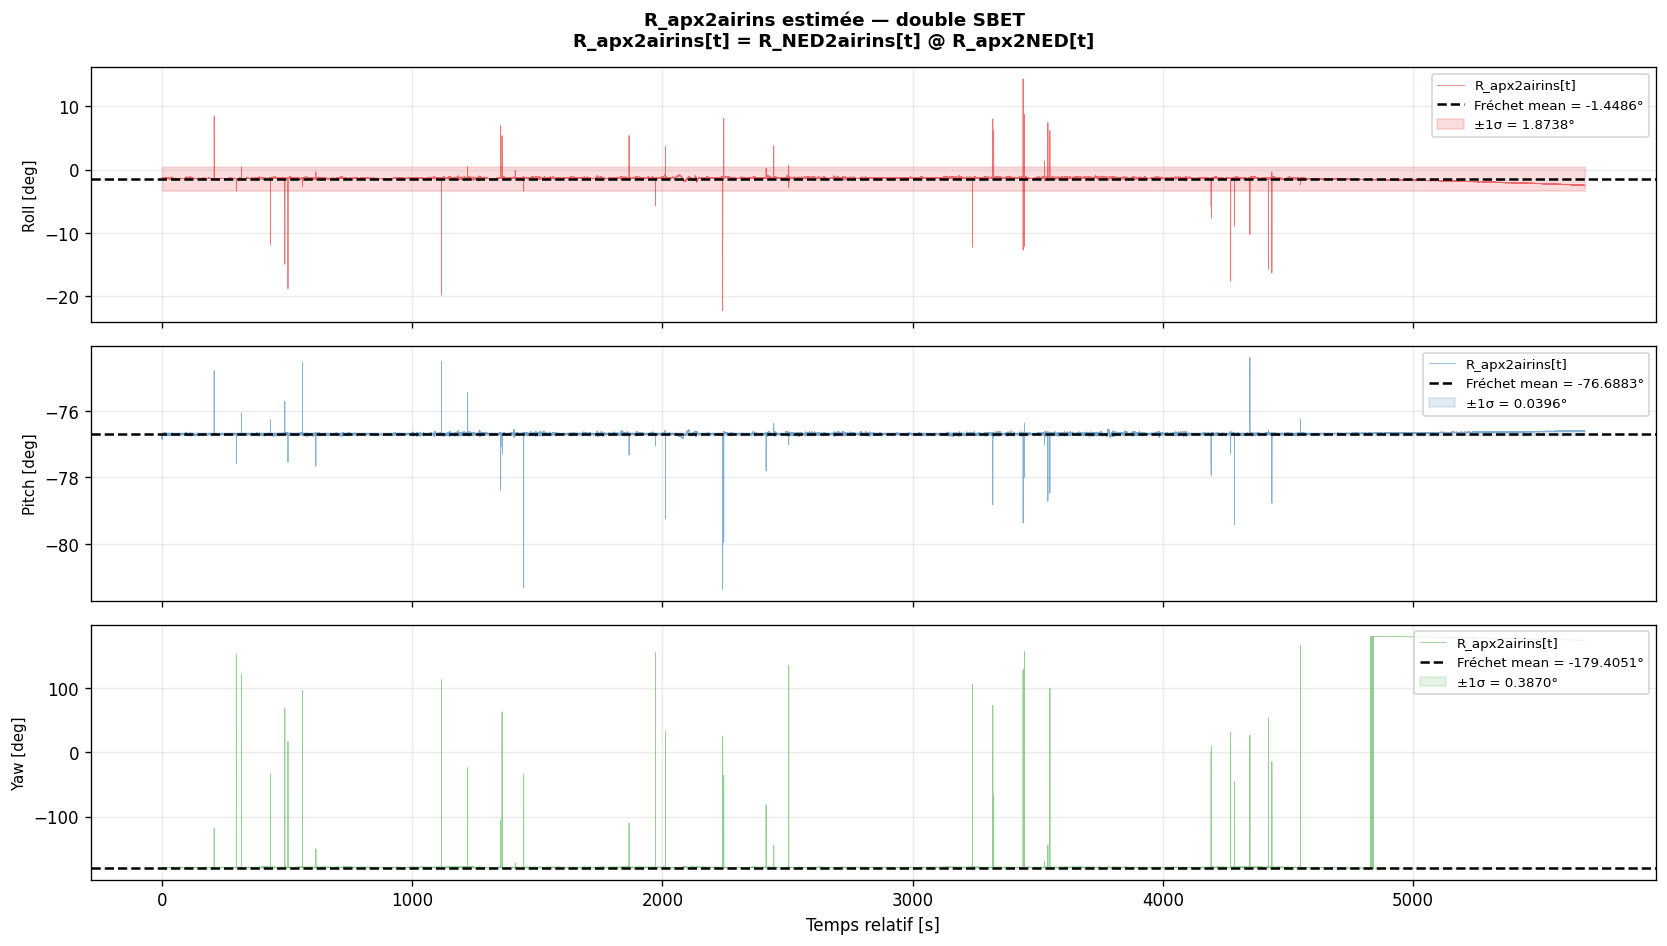

In [82]:
rpy_seq = R.from_matrix(R_apx2airins_seq).as_euler('xyz', degrees=True)
t_rel   = t_grid - t_grid[0]
labels  = ['Roll [deg]', 'Pitch [deg]', 'Yaw [deg]']
colors  = ['#e41a1c', '#377eb8', '#4daf4a']

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for i, (ax, lbl, col) in enumerate(zip(axes, labels, colors)):
    ax.plot(t_rel, rpy_seq[:, i], color=col, lw=0.5, alpha=0.6, label='R_apx2airins[t]')
    ax.axhline(rpy_mean[i], color='k', lw=1.5, ls='--',
               label=f'Fréchet mean = {rpy_mean[i]:.4f}°')
    ax.fill_between(t_rel,
                    rpy_mean[i] - std_deg[i],
                    rpy_mean[i] + std_deg[i],
                    alpha=0.15, color=col, label=f'±1σ = {std_deg[i]:.4f}°')
    ax.set_ylabel(lbl, fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Temps relatif [s]')
fig.suptitle('R_apx2airins estimée — double SBET\n'
             'R_apx2airins[t] = R_NED2airins[t] @ R_apx2NED[t]',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [83]:
print('='*60)
print('R_apx2airins_sbet = np.array([')
for row in R_mean:
    print('    [' + ', '.join(f'{v:+.10f}' for v in row) + '],')
print('])')
print(f'\ndet        = {np.linalg.det(R_mean):.8f}')
print(f'orth err   = {np.max(np.abs(R_mean @ R_mean.T - np.eye(3))):.2e}')
print(f'RPY (deg)  = {rpy_mean.round(4)}')
print(f'1σ  (deg)  = {std_deg.round(4)}')

R_apx2airins_sbet = np.array([
    [-0.2302367669, -0.0142206582, +0.9730307313],
    [-0.0023905147, -0.9998819389, -0.0151787227],
    [+0.9731317057, -0.0058207443, +0.2301755902],
])

det        = 1.00000000
orth err   = 4.44e-16
RPY (deg)  = [  -1.4486  -76.6883 -179.4051]
1σ  (deg)  = [1.8738 0.0396 0.387 ]


In [84]:
import numpy as np

# R_AIRINS2body — ce qu'odyn utilise pour l'AIRINS (ENU↔NED = T())
R_AIRINS2body = np.array([[0, 1, 0],
                           [1, 0, 0],
                           [0, 0,-1]], dtype=float)

# R_APX2AIRINS — estimée par double SBET
R_APX2AIRINS = np.array([[-0.230237, -0.014221,  0.973031],
                          [-0.002391, -0.999882, -0.015179],
                          [ 0.973132, -0.005821,  0.230176]])

# R_imu2body = R_AIRINS2body @ R_APX2AIRINS
R_imu2body = R_AIRINS2body @ R_APX2AIRINS

print("R_imu2body :\n", np.round(R_imu2body, 6))
print(f"det = {np.linalg.det(R_imu2body):.6f}")

from scipy.spatial.transform import Rotation as R
q = R.from_matrix(R_imu2body).as_quat()  # [x,y,z,w]
w, x, y, z = q[3], q[0], q[1], q[2]
print(f'\nQuaternion [w, x, y, z] pour odyn :')
print(f'w={w:.10f}')
print(f'x={x:.10f}')
print(f'y={y:.10f}')
print(f'z={z:.10f}')

R_imu2body :
 [[-0.002391 -0.999882 -0.015179]
 [-0.230237 -0.014221  0.973031]
 [-0.973132  0.005821 -0.230176]]
det = 1.000001

Quaternion [w, x, y, z] pour odyn :
w=-0.4339391870
x=0.5572265319
y=-0.5518934241
z=-0.4434061598


In [85]:
import numpy as np
from scipy.spatial.transform import Rotation as R

R_AIRINS2body = np.array([[0, 1, 0],
                           [1, 0, 0],
                           [0, 0,-1]], dtype=float)

# R_total validée empiriquement
R_APX2AIRINS = np.array([[ 0.002514, -0.999993, -0.002859],
                          [ 0.972837,  0.001784,  0.231485],
                          [-0.231478, -0.003363,  0.972834]])

R_imu2body = R_AIRINS2body @ R_APX2AIRINS
print("R_imu2body :\n", np.round(R_imu2body, 6))
print(f"det = {np.linalg.det(R_imu2body):.8f}")

q = R.from_matrix(R_imu2body).as_quat()
w, x, y, z = q[3], q[0], q[1], q[2]
print(f'\nw={w:.10f}')
print(f'x={x:.10f}')
print(f'y={y:.10f}')
print(f'z={z:.10f}')

R_imu2body :
 [[ 0.972837  0.001784  0.231485]
 [ 0.002514 -0.999993 -0.002859]
 [ 0.231478  0.003363 -0.972834]]
det = 1.00000009

w=0.0015661738
x=0.9931847661
y=0.0010818732
z=0.1165349606


In [87]:
# Inverser les signes de la correction
roll_res  = np.radians(+0.514)   # était -0.514
pitch_res = np.radians(+0.085)   # était -0.085
yaw_res   = np.radians(-0.007)   # négligeable

R_corr = R.from_euler('xyz', [roll_res, pitch_res, yaw_res]).as_matrix()

# Correction à gauche
R_imu2body_v3 = R_corr @ R_imu2body  # R_imu2body original, pas v2 !

print("R_imu2body_v3 :\n", np.round(R_imu2body_v3, 8))
print(f"det = {np.linalg.det(R_imu2body_v3):.8f}")

q = R.from_matrix(R_imu2body_v3).as_quat()
w, x, y, z = q[3], q[0], q[1], q[2]
print(f'\nw={w:.10f}')
print(f'x={x:.10f}')
print(f'y={y:.10f}')
print(f'z={z:.10f}')

R_imu2body_v3 :
 [[ 9.7317940e-01  1.6535100e-03  2.3004225e-01]
 [ 3.1844000e-04 -9.9998314e-01  5.8401800e-03]
 [ 2.3004775e-01 -5.6105800e-03 -9.7316285e-01]]
det = 1.00000009

w=-0.0028820933
x=0.9932680031
y=0.0004963289
z=0.1158020779


## fonctionne:

In [89]:
import numpy as np
from scipy.spatial.transform import Rotation as R

R_AIRINS2body = np.array([[0, 1, 0],
                           [1, 0, 0],
                           [0, 0,-1]], dtype=float)

# R_total validée empiriquement
R_APX2AIRINS = np.array([[ 0.002514, -0.999993, -0.002859],
                          [ 0.972837,  0.001784,  0.231485],
                          [-0.231478, -0.003363,  0.972834]])

R_imu2body = R_AIRINS2body @ R_APX2AIRINS
print("R_imu2body :\n", np.round(R_imu2body, 6))
print(f"det = {np.linalg.det(R_imu2body):.8f}")

q = R.from_matrix(R_imu2body).as_quat()
w, x, y, z = q[3], q[0], q[1], q[2]
print(f'\nw={w:.10f}')
print(f'x={x:.10f}')
print(f'y={y:.10f}')
print(f'z={z:.10f}')

R_imu2body :
 [[ 0.972837  0.001784  0.231485]
 [ 0.002514 -0.999993 -0.002859]
 [ 0.231478  0.003363 -0.972834]]
det = 1.00000009

w=0.0015661738
x=0.9931847661
y=0.0010818732
z=0.1165349606


## iteration boresight

In [99]:
import numpy as np
from scipy.spatial.transform import Rotation as R

# Correction boresight en degrés — à ajuster selon résidus odyn
roll_deg  = 0.0067
pitch_deg = 0.001
yaw_deg   = -0.004

R_bs = R.from_euler('xyz', [np.radians(roll_deg),
                              np.radians(pitch_deg),
                              np.radians(yaw_deg)]).as_matrix()

R_imu2body = np.array([[ 9.73175e-01,  1.77600e-03 , 2.30059e-01],
                        [ 4.37000e-04 ,-9.99983e-01,  5.86800e-03],
                        [ 2.30065e-01 ,-5.61100e-03, -9.73159e-01]])


# Chaîne complète :
# R_imu2body = R_bs @ R_imu2body
R_imu2body =  R_bs @ R_imu2body

print("R_imu2body :\n", np.round(R_imu2body, 6))
print(f"det = {np.linalg.det(R_imu2body):.8f}")

q = R.from_matrix(R_imu2body).as_quat()
w, x, y, z = q[3], q[0], q[1], q[2]
print(f'\nw={w:.10f}')
print(f'x={x:.10f}')
print(f'y={y:.10f}')
print(f'z={z:.10f}')

R_imu2body :
 [[ 9.73179e-01  1.70600e-03  2.30042e-01]
 [ 3.42000e-04 -9.99982e-01  5.96600e-03]
 [ 2.30048e-01 -5.72800e-03 -9.73162e-01]]
det = 1.00000016

w=-0.0029432405
x=0.9932677970
y=0.0005155317
z=0.1158022237
